# Random Traversal

In [78]:
import networkx as nx
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import heapq
from collections import defaultdict

In [79]:
SEED = 42          #a resposta para o universo e todas as coisas hehe
N_RUNS = 100      
GRAPHML_PATH = "../graphs-and-analysis/instancias/grafo_bipartido.graphml"

In [80]:
print("Lendo o grafo... (pode demorar alguns segundos)")
G = nx.read_graphml(GRAPHML_PATH)
print(f"Grafo carregado: {G.number_of_nodes()} nós, {G.number_of_edges()} arestas")
 
movie_nodes = {n for n, d in G.nodes(data=True) if d.get("tipo") == "filme"}
actor_nodes  = {n for n, d in G.nodes(data=True) if d.get("tipo") == "ator"}
 
print(f"  Filmes : {len(movie_nodes)}")
print(f"  Atores : {len(actor_nodes)}")


Lendo o grafo... (pode demorar alguns segundos)
Grafo carregado: 28349 nós, 48241 arestas
  Filmes : 9671
  Atores : 18678


In [81]:
def find_node_by_label(G, name_fragment, node_type=None):
    """Retorna lista de (node_id, atributos) cujo label contém name_fragment."""
    results = []
    for n, d in G.nodes(data=True):
        if node_type and d.get("tipo") != node_type:
            continue
        if name_fragment.lower() in str(d.get("label", "")).lower():
            results.append((n, d))
    return results

In [82]:
def resolve_actors(names: list[str]) -> set:
    """Busca cada nome no grafo; imprime aviso se não encontrar."""
    ids = set()
    for name in names:
        matches = find_node_by_label(G, name, node_type="ator")
        if not matches:
            print(f"  ⚠️  {name} não está no grafo")
        else:
            # Se tiver mais de um, assumimos que o que tem oscar é o mais famoso e trabalha em mais filmes
            best = max(matches, key=lambda x: G.degree(x[0]))
            ids.add(best[0])
    return ids
 

In [83]:
def resolve_movies(titles: list[str]) -> set:
    """Busca cada título no grafo; imprime aviso se não encontrar."""
    ids = set()
    for title in titles:
        matches = find_node_by_label(G, title, node_type="filme")
        if not matches:
            print(f"  ⚠️  '{title}' não está no grafo")
        else:
            best = max(matches, key=lambda x: G.degree(x[0]))
            ids.add(best[0])
    return ids

In [84]:
OSCAR_ACTING_NAMES = [
    # 94ª (2022) — filmes de 2021
    # Ator Principal
    "Will Smith", "Javier Bardem", "Benedict Cumberbatch",
    "Andrew Garfield", "Denzel Washington",
    # Ator Coadjuvante
    "Troy Kotsur", "Ciarán Hinds", "Jesse Plemons",
    "J.K. Simmons", "Kodi Smit-McPhee",
    # Atriz Principal
    "Jessica Chastain", "Olivia Colman", "Penélope Cruz",
    "Nicole Kidman", "Kristen Stewart",
    # Atriz Coadjuvante
    "Ariana DeBose", "Jessie Buckley", "Judi Dench",
    "Kirsten Dunst", "Aunjanue Ellis",
 
    # 95ª (2023) — filmes de 2022
    # Ator Principal
    "Brendan Fraser", "Austin Butler", "Colin Farrell",
    "Paul Mescal", "Bill Nighy",
    # Ator Coadjuvante
    "Ke Huy Quan", "Brendan Gleeson", "Brian Tyree Henry",
    "Judd Hirsch", "Barry Keoghan",
    # Atriz Principal
    "Michelle Yeoh", "Cate Blanchett", "Ana de Armas",
    "Andrea Riseborough", "Michelle Williams",
    # Atriz Coadjuvante
    "Jamie Lee Curtis", "Angela Bassett", "Hong Chau",
    "Kerry Condon", "Stephanie Hsu",
 
    # 96ª (2024) — filmes de 2023
    # Ator Principal
    "Cillian Murphy", "Bradley Cooper", "Colman Domingo",
    "Paul Giamatti", "Jeffrey Wright",
    # Ator Coadjuvante
    "Robert Downey Jr.", "Sterling K. Brown", "Robert De Niro",
    "Ryan Gosling", "Mark Ruffalo",
    # Atriz Principal
    "Emma Stone", "Annette Bening", "Lily Gladstone",
    "Sandra Hüller", "Carey Mulligan",
    # Atriz Coadjuvante
    "Da'Vine Joy Randolph", "Emily Blunt", "Danielle Brooks",
    "America Ferrera", "Jodie Foster",
 
    # 97ª (2025) — filmes de 2024
    # Ator Principal
    "Adrien Brody", "Timothée Chalamet", "Colman Domingo",
    "Ralph Fiennes", "Sebastian Stan",
    # Ator Coadjuvante
    "Kieran Culkin", "Yura Borisov", "Edward Norton",
    "Guy Pearce", "Jeremy Strong",
    # Atriz Principal
    "Mikey Madison", "Cynthia Erivo", "Karla Sofía Gascón",
    "Demi Moore", "Fernanda Torres",
    # Atriz Coadjuvante
    "Zoe Saldaña", "Monica Barbaro", "Ariana Grande",
    "Felicity Jones", "Isabella Rossellini",
 
    # 98ª (2026) — filmes de 2025
    # Ator Principal
    "Michael B. Jordan", "Timothée Chalamet", "Leonardo DiCaprio",
    "Ethan Hawke", "Wagner Moura",
    # Ator Coadjuvante
    "Sean Penn", "Stellan Skarsgård", "Benicio del Toro",
    "Paul Mescal", "Jacob Elordi",
    # Atriz Principal
    "Jessie Buckley", "Rose Byrne", "Kate Hudson",
    "Renate Reinsve", "Emma Stone",
    # Atriz Coadjuvante
    "Amy Madigan", "Elle Fanning", "Inga Ibsdotter Lilleaas",
    "Wunmi Mosaku", "Teyana Taylor",
]

In [85]:
print("Buscando atores indicados ao Oscar no grafo...")
OSCAR_ACTORS_IDS  = resolve_actors(OSCAR_ACTING_NAMES)
print(f"  → {len(OSCAR_ACTORS_IDS)} atores encontrados de {len(set(OSCAR_ACTING_NAMES))} nomes únicos\n")

Buscando atores indicados ao Oscar no grafo...
  ⚠️  Troy Kotsur não está no grafo
  → 94 atores encontrados de 95 nomes únicos



In [86]:
def get_brazilian_actors(G) -> set:
    """Atores com 'Brazil' em local_nascimento."""
    return {
        n for n, d in G.nodes(data=True)
        if d.get("tipo") == "ator"
        and "Brazil" in str(d.get("local_nascimento", ""))
    }

In [87]:
def get_female_actors(G) -> set:
    """Atores com genero == 'feminino'."""
    return {
        n for n, d in G.nodes(data=True)
        if d.get("tipo") == "ator"
        and d.get("genero") == "feminino"
    }

In [88]:
def get_oscar_actors(G, oscar_actor_ids: set) -> set:
    """Atores indicados ao Oscar (lista manual)."""
    return {n for n in oscar_actor_ids if n in G.nodes}

In [89]:
def get_genz_actors(G) -> set:
    """Atores com data_nascimento entre 1997-01-01 e 2012-12-31."""
    genz = set()
    for n, d in G.nodes(data=True):
        if d.get("tipo") == "ator":
            # Pega a data e remove espaços em branco por segurança
            nascimento = str(d.get("data_nascimento", "")).strip()
            # Verifica se tem pelo menos 10 caracteres (YYYY-MM-DD) e faz a comparação
            if len(nascimento) >= 10 and "1997-01-01" <= nascimento[:10] <= "2012-12-31":
                genz.add(n)
    return genz

In [90]:
def get_deceased_actors(G) -> set:
    """Atores que já faleceram (atributo morto == 'Sim')."""
    return {
        n for n, d in G.nodes(data=True)
        if d.get("tipo") == "ator"
        and str(d.get("morto", "")).strip() == "Sim"
    }

In [91]:
subsets = {
    "Atores Brasileiros"       : get_brazilian_actors(G),
    "Atrizes (feminino)"       : get_female_actors(G),
    "Indicados Oscar (atores)" : get_oscar_actors(G, OSCAR_ACTORS_IDS),
    "Geração Z"                : get_genz_actors(G),
    "Atores Falecidos"        : get_deceased_actors(G),
}
 
for name, s in subsets.items():
    print(f"{name}: {len(s)} nós")

Atores Brasileiros: 78 nós
Atrizes (feminino): 7316 nós
Indicados Oscar (atores): 94 nós
Geração Z: 1111 nós
Atores Falecidos: 3032 nós


In [92]:
def movie_rating(G, movie_node: str) -> float:
    """Retorna a nota de um filme (atributo 'nota' do nó)."""
    return float(G.nodes[movie_node].get("nota", 0))

In [93]:
def random_coverage_actors(
    G,
    target_actors: set,
    candidate_movies: set = None,
    seed: int = None,
) -> dict:
    """
    Cobre `target_actors` escolhendo filmes aleatoriamente.
 
    Parameters
    ----------
    G                : grafo bipartido NetworkX
    target_actors    : conjunto de nós de atores a cobrir
    candidate_movies : filmes candidatos (None = todos os filmes do grafo)
    seed             : semente para reprodutibilidade
 
    Returns
    -------
    dict com n_films, avg_rating, median_rating, min_rating, selected_films, uncovered
    """
    rng = random.Random(seed)
 
    candidates = list(candidate_movies if candidate_movies is not None else movie_nodes)
 
    # Pré-computa quais atores do target cada filme cobre
    film_to_target = {
        m: {nb for nb in G.neighbors(m) if nb in target_actors}
        for m in candidates
    }
    film_to_target = {m: s for m, s in film_to_target.items() if s}
 
    available = list(film_to_target.keys())
    rng.shuffle(available)
 
    uncovered = set(target_actors)
    selected  = []
 
    for film in available:
        if not uncovered:
            break
        newly_covered = film_to_target[film] & uncovered
        if newly_covered:
            selected.append(film)
            uncovered -= newly_covered
 
    ratings = [movie_rating(G, m) for m in selected]
    return {
        "n_films"       : len(selected),
        "avg_rating"    : float(np.mean(ratings))   if ratings else 0.0,
        "median_rating" : float(np.median(ratings)) if ratings else 0.0,
        "min_rating"    : float(np.min(ratings))    if ratings else 0.0,
        "selected_films": selected,
        "uncovered"     : len(uncovered),
    }
 

In [97]:
def run_experiment(subset_name: str, subset: set, n_runs: int = N_RUNS) -> pd.DataFrame:
    """Executa N_RUNS do algoritmo aleatório e retorna DataFrame de resultados."""
    results = []

 
    for i in range(n_runs):
        res = random_coverage_actors(G, subset, seed=i)
        results.append({
            "run"          : i,
            "n_films"      : res["n_films"],
            "avg_rating"   : res["avg_rating"],
            "median_rating": res["median_rating"],
            "min_rating"   : res["min_rating"],
            "uncovered"    : res["uncovered"],
        })
 
    df = pd.DataFrame(results)
    print(f"\n{'='*52}")
    print(f"Subconjunto: {subset_name}  ({len(subset)} nós)")
    print(f"{'='*52}")
    print(f"  Filmes selecionados — média: {df['n_films'].mean():.1f}"
          f"  ± {df['n_films'].std():.1f}"
          f"  [min={df['n_films'].min()}, max={df['n_films'].max()}]")
    print(f"  Nota média          — média: {df['avg_rating'].mean():.3f}"
          f"  ± {df['avg_rating'].std():.3f}")
    print(f"  Nota mediana        — média: {df['median_rating'].mean():.3f}"
          f"  ± {df['median_rating'].std():.3f}")
    print(f"  Nota mínima         — média: {df['min_rating'].mean():.3f}"
          f"  ± {df['min_rating'].std():.3f}")
    if df["uncovered"].sum() > 0:
        print(f"  ⚠️  Runs com cobertura incompleta: {(df['uncovered'] > 0).sum()}")
    return df


In [98]:
all_results = {}
for name, subset in subsets.items():
    if len(subset) == 0:
        print(f"\n[SKIP] {name}: subconjunto vazio (verifique os IDs manuais)")
        continue
    all_results[name] = run_experiment(name, subset)


Subconjunto: Atores Brasileiros  (78 nós)
  Filmes selecionados — média: 40.8  ± 1.3  [min=38, max=44]
  Nota média          — média: 7.081  ± 0.034
  Nota mediana        — média: 7.107  ± 0.058
  Nota mínima         — média: 5.547  ± 0.000

Subconjunto: Atrizes (feminino)  (7316 nós)
  Filmes selecionados — média: 4824.1  ± 19.0  [min=4783, max=4869]
  Nota média          — média: 6.662  ± 0.004
  Nota mediana        — média: 6.700  ± 0.000
  Nota mínima         — média: 2.893  ± 0.095

Subconjunto: Indicados Oscar (atores)  (94 nós)
  Filmes selecionados — média: 85.8  ± 2.4  [min=79, max=91]
  Nota média          — média: 6.760  ± 0.071
  Nota mediana        — média: 6.809  ± 0.090
  Nota mínima         — média: 4.851  ± 0.410

Subconjunto: Geração Z  (1111 nós)
  Filmes selecionados — média: 827.2  ± 5.6  [min=813, max=839]
  Nota média          — média: 6.724  ± 0.010
  Nota mediana        — média: 6.721  ± 0.015
  Nota mínima         — média: 3.486  ± 0.000

Subconjunto: Atores 

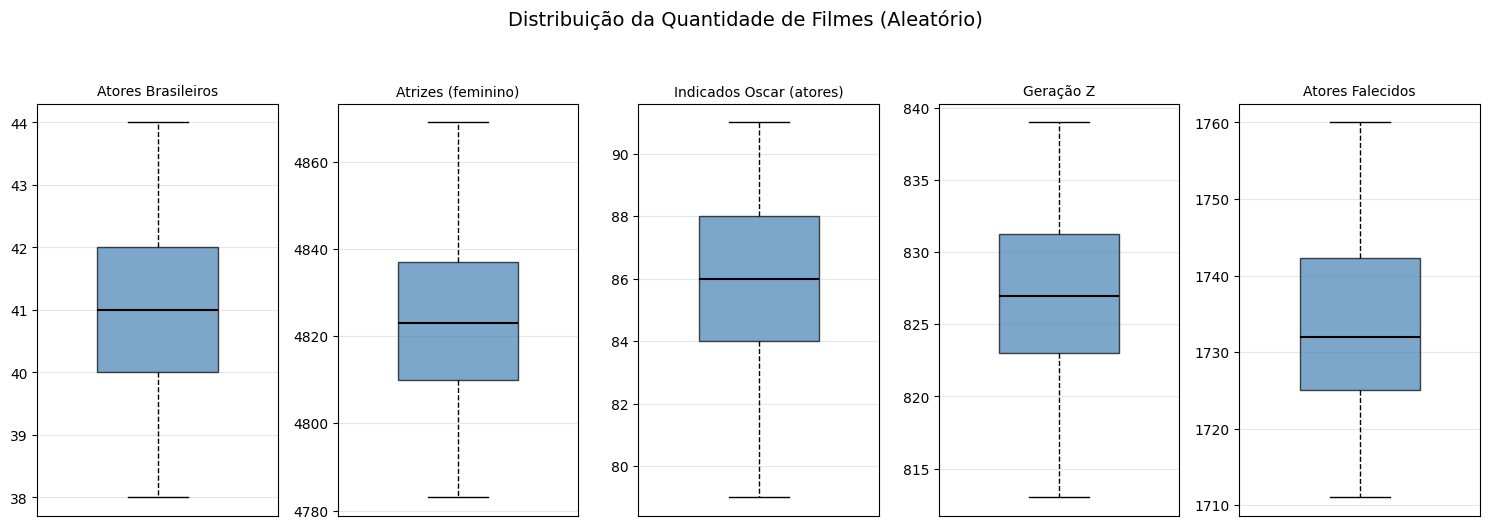

In [99]:
subsets_to_plot = [name for name in all_results if len(all_results[name]) > 0]
n_subsets = len(subsets_to_plot)

fig, axes = plt.subplots(1, n_subsets, figsize=(15, 5), sharey=False)
if n_subsets == 1:
    axes = [axes]

for ax, name in zip(axes, subsets_to_plot):
    df_rand = all_results[name]
    
    # Boxplot matplotlib clássico
    bp = ax.boxplot(
        df_rand["n_films"].values,
        widths=0.5,
        patch_artist=True,
        boxprops=dict(facecolor='steelblue', alpha=0.7),
        medianprops=dict(color='black', linewidth=1.5),
        whiskerprops=dict(linestyle='--')
    )
    
    ax.set_title(name, fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    # Remove o tick do eixo X
    ax.set_xticks([])

fig.suptitle("Distribuição da Quantidade de Filmes (Aleatório)", fontsize=14, y=1.05)
plt.tight_layout()
plt.savefig("boxplot_quantidade_aleatorio.png", dpi=150, bbox_inches='tight')
plt.show()


/tmp/ipykernel_121907/2419748448.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


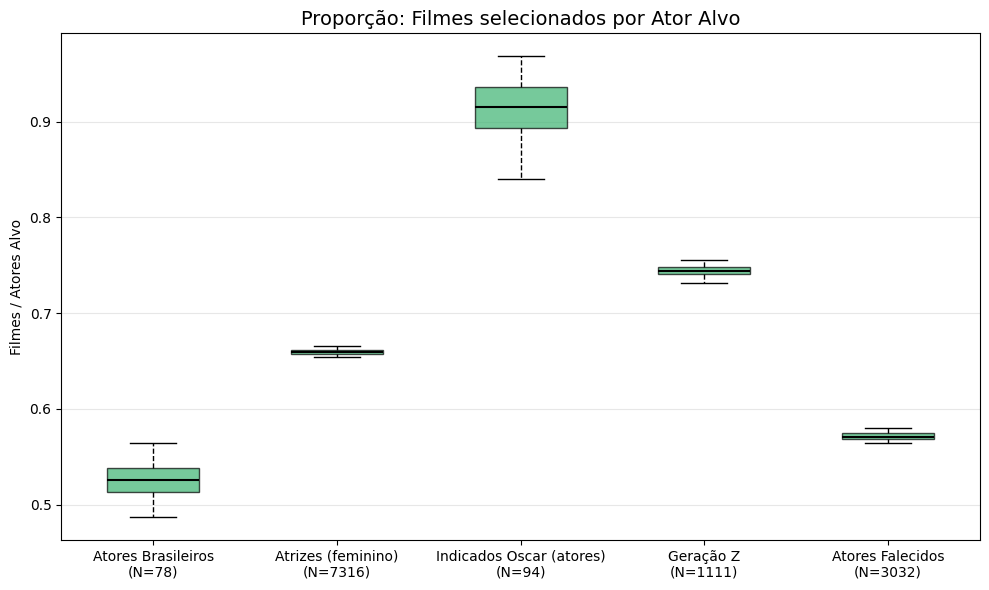

In [100]:
target_size_by_subset = {}
for name, subset in subsets.items():
    if not subset:
        continue
    sample_node = next(iter(subset))
    if G.nodes[sample_node].get("tipo") == "filme":
        # Extrai os atores se o subset for de filmes
        target_actors = {nb for m in subset for nb in G.neighbors(m) if nb in actor_nodes}
        target_size_by_subset[name] = len(target_actors)
    else:
        target_size_by_subset[name] = len(subset)

fig, ax = plt.subplots(figsize=(10, 6))

data_to_plot = []
labels = []
for name in subsets_to_plot:
    df_rand = all_results[name]
    n_target = target_size_by_subset[name]
    
    # Proporção = numero de filmes precisos / atores para cobrir
    proportions = df_rand["n_films"].values / n_target
    data_to_plot.append(proportions)
    labels.append(f"{name}\n(N={n_target})")

ax.boxplot(
    data_to_plot,
    labels=labels,
    patch_artist=True,
    boxprops=dict(facecolor='mediumseagreen', alpha=0.7),
    medianprops=dict(color='black', linewidth=1.5),
    whiskerprops=dict(linestyle='--')
)

ax.set_title("Proporção: Filmes selecionados por Ator Alvo", fontsize=14)
ax.set_ylabel("Filmes / Atores Alvo")
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("boxplot_proporcao_aleatorio.png", dpi=150)
plt.show()


In [101]:
def greedy_coverage_actors_heap(
    G,
    target_actors: set,
    candidate_movies: set | None = None,
):
    """Versão otimizada do greedy_coverage_actors usando heap e contadores.

    A lógica é equivalente: sempre escolhe o filme que cobre o maior número de
    atores ainda não cobertos (desempate por ID do nó para manter determinismo),
    mas evita recomputar interseções completas a cada iteração.

    Parameters
    ----------
    G : grafo bipartido NetworkX
    target_actors : conjunto de nós de atores a cobrir
    candidate_movies : filmes candidatos (None = todos os filmes do grafo)

    Returns
    -------
    dict com n_films, avg_rating, median_rating, min_rating,
    selected_films, uncovered
    """

    # Conjunto de filmes candidatos
    candidates = candidate_movies if candidate_movies is not None else movie_nodes

    # Para cada filme, quais atores-alvo ele cobre
    film_to_target = {
        m: {nb for nb in G.neighbors(m) if nb in target_actors}
        for m in candidates
    }
    # Remove filmes que não cobrem ninguém do target
    film_to_target = {m: s for m, s in film_to_target.items() if s}

    uncovered = set(target_actors)
    selected: list[str] = []

    if not uncovered or not film_to_target:
        # Nenhum ator para cobrir ou nenhum filme útil
        ratings = [movie_rating(G, m) for m in selected]
        return {
            "n_films": len(selected),
            "avg_rating": float(np.mean(ratings)) if ratings else 0.0,
            "median_rating": float(np.median(ratings)) if ratings else 0.0,
            "min_rating": float(np.min(ratings)) if ratings else 0.0,
            "selected_films": selected,
            "uncovered": len(uncovered),
        }

    # Contador de quantos atores ainda não cobertos cada filme cobre
    cover_count = {m: len(s) for m, s in film_to_target.items()}

    # Heap de máximo via valores negativos; guardamos também o ID para desempate
    heap: list[tuple[int, str]] = [(-cover_count[m], m) for m in film_to_target]
    heapq.heapify(heap)

    # Pré-computa m -> atores que ele cobre (já está em film_to_target)
    # Também precisamos de um mapa ator -> filmes para atualizar contagens
    actor_to_films: dict[str, set[str]] = {}
    for m, actors in film_to_target.items():
        for a in actors:
            actor_to_films.setdefault(a, set()).add(m)

    while uncovered and heap:
        # Extrai o melhor filme atual (lazy update para lidar com contagens defasadas)
        neg_cnt, film = heapq.heappop(heap)
        cnt = -neg_cnt

        # Se a contagem estiver defasada, ignora essa entrada do heap
        if cover_count.get(film, 0) != cnt:
            continue

        if cnt == 0:
            # Nenhum filme restante cobre atores pendentes
            break

        # Seleciona esse filme
        selected.append(film)

        # Atores efetivamente novos que ele cobre nesta iteração
        newly_covered = film_to_target[film] & uncovered
        if not newly_covered:
            continue

        # Remove esses atores do conjunto de uncovered
        uncovered -= newly_covered

        # Para cada ator recém coberto, diminui 1 da contagem de todos os filmes
        # que o continham
        for a in newly_covered:
            for other_film in actor_to_films.get(a, ()):  # pode ser o próprio "film"
                if other_film in cover_count and cover_count[other_film] > 0:
                    cover_count[other_film] -= 1
                    # Reinsere no heap com a nova contagem
                    heapq.heappush(heap, (-cover_count[other_film], other_film))

    ratings = [movie_rating(G, m) for m in selected]
    return {
        "n_films": len(selected),
        "avg_rating": float(np.mean(ratings)) if ratings else 0.0,
        "median_rating": float(np.median(ratings)) if ratings else 0.0,
        "min_rating": float(np.min(ratings)) if ratings else 0.0,
        "selected_films": selected,
        "uncovered": len(uncovered),
    }


In [102]:
def run_greedy_experiment_heap(subset_name: str, subset: set) -> dict:
    """Executa o algoritmo guloso com heap (1 run, determinístico) e imprime resumo."""

    res = greedy_coverage_actors_heap(G, subset)

    print(f"{'='*52}")
    print(f"Subconjunto (GULOSO HEAP): {subset_name} ({len(subset)} nós)")
    print(f"{'='*52}")
    print(f" Filmes selecionados : {res['n_films']}")
    print(f" Nota média : {res['avg_rating']:.3f}")
    print(f" Nota mediana : {res['median_rating']:.3f}")
    print(f" Nota mínima : {res['min_rating']:.3f}")
    if res["uncovered"] > 0:
        print(f" ⚠️ Atores não cobertos: {res['uncovered']}")
    return res


In [103]:
greedy_results = {}
for name, subset in subsets.items():
    if len(subset) == 0:
        print(f"\n[SKIP] {name}: subconjunto vazio")
        continue
    greedy_results[name] = run_greedy_experiment_heap(name, subset)

Subconjunto (GULOSO HEAP): Atores Brasileiros (78 nós)
 Filmes selecionados : 36
 Nota média : 7.159
 Nota mediana : 7.200
 Nota mínima : 5.547
Subconjunto (GULOSO HEAP): Atrizes (feminino) (7316 nós)
 Filmes selecionados : 4097
 Nota média : 6.664
 Nota mediana : 6.700
 Nota mínima : 3.000
Subconjunto (GULOSO HEAP): Indicados Oscar (atores) (94 nós)
 Filmes selecionados : 51
 Nota média : 6.668
 Nota mediana : 6.774
 Nota mínima : 5.290
Subconjunto (GULOSO HEAP): Geração Z (1111 nós)
 Filmes selecionados : 748
 Nota média : 6.724
 Nota mediana : 6.718
 Nota mínima : 3.486
Subconjunto (GULOSO HEAP): Atores Falecidos (3032 nós)
 Filmes selecionados : 1487
 Nota média : 6.908
 Nota mediana : 7.000
 Nota mínima : 2.800


In [106]:
rows = []
for name in all_results:
    if name not in greedy_results:
        continue
    df_rand = all_results[name]
    g       = greedy_results[name]
 
    rand_mean_films = df_rand["n_films"].mean()
    reducao_pct     = (1 - g["n_films"] / rand_mean_films) * 100
 
    rows.append({
        "Subconjunto"                    : name,
        "Aleat. filmes (média ± std)"    : f"{rand_mean_films:.1f} ± {df_rand['n_films'].std():.1f}",
        "Guloso filmes"                  : g["n_films"],
        "Redução (%)"                    : f"{reducao_pct:.1f}%",
        "Aleat. nota média"              : f"{df_rand['avg_rating'].mean():.3f}",
        "Guloso nota média"              : f"{g['avg_rating']:.3f}",
        "Δ nota"                         : f"{g['avg_rating'] - df_rand['avg_rating'].mean():+.3f}",
    })
 
comparison_table = pd.DataFrame(rows).set_index("Subconjunto")
print("\nTabela Comparativa: Aleatório × Guloso")
print("=" * 95)
print(comparison_table.to_string())



Tabela Comparativa: Aleatório × Guloso
                         Aleat. filmes (média ± std)  Guloso filmes Redução (%) Aleat. nota média Guloso nota média  Δ nota
Subconjunto                                                                                                                
Atores Brasileiros                        40.8 ± 1.3             36       11.9%             7.081             7.159  +0.079
Atrizes (feminino)                     4824.1 ± 19.0           4097       15.1%             6.662             6.664  +0.003
Indicados Oscar (atores)                  85.8 ± 2.4             51       40.6%             6.760             6.668  -0.092
Geração Z                                827.2 ± 5.6            748        9.6%             6.724             6.724  +0.001
Atores Falecidos                       1733.4 ± 11.2           1487       14.2%             6.895             6.908  +0.014


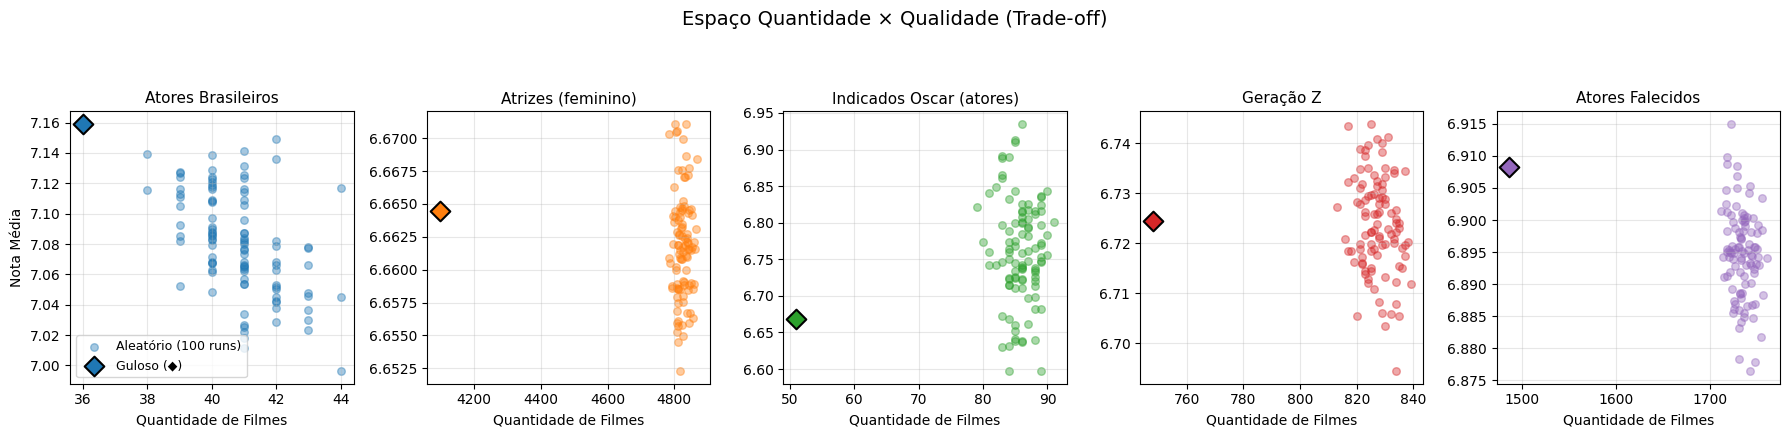

In [105]:
fig, axes = plt.subplots(1, n_subsets, figsize=(18, 4), sharex=False, sharey=False)
if n_subsets == 1:
    axes = [axes]

colors = plt.cm.tab10.colors

for i, (ax, name) in enumerate(zip(axes, subsets_to_plot)):
    if name not in greedy_results:
        continue
        
    df_rand = all_results[name]
    g_res = greedy_results[name]
    
    # Nuvem do Aleatório
    ax.scatter(
        df_rand["n_films"], df_rand["avg_rating"],
        alpha=0.4, s=30, color=colors[i % len(colors)], label="Aleatório (100 runs)"
    )
    
    # Ponto do Guloso
    ax.scatter(
        g_res["n_films"], g_res["avg_rating"],
        marker="D", s=100, color=colors[i % len(colors)], zorder=5,
        edgecolors="black", linewidth=1.5, label="Guloso (◆)"
    )
    
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("Quantidade de Filmes")
    if i == 0:
        ax.set_ylabel("Nota Média")
    ax.grid(alpha=0.3)
    
    # Simplifica a legenda para aparecer só no primeiro gráfico
    if i == 0:
        ax.legend(fontsize=9, loc="best")

fig.suptitle("Espaço Quantidade × Qualidade (Trade-off)", fontsize=14, y=1.08)
plt.tight_layout()
plt.savefig("scatter_pareto_subplots.png", dpi=150, bbox_inches='tight')
plt.show()